# Dataset Description

#### This work presents 5G-NIDD, a fully labeled dataset built on a functional 5G test network that can be used by those who develop and test AI/ML solutions. 5G-NIDD contains data extracted from a 5G testbed. The testbed is attached to 5G Test Network in University of Oulu, Finland. The data are extracted from tow base stations, each having an attacker node, several benign 5G users. The attacker nodes attack the server deployed in 5GTN MEC environment. The attack scenarios include DoS attacks and port scans. Under DoS attacks, the dataset contains ICMP Flood, UDP Flood, SYN Flood, HTTP Flood, and Slowrate DoS. Under port scans, the dataset contains SYN Scan, TCP Connect Scan, and UDP Scan. The dataset files are available in different formats. These files belong to a network intrusion series of post-processing steps from network capture (pcapng) to encoded data (csv) ready to feed ML algorithms.

# Abbreviations
- **Seq:** Sequence
- **Dur:** Duration
- **RunTime:** Runtime
- **Mean:** Mean
- **Sum:** Summation
- **Min:** Minimum
- **Max:** Maximum
- **Proto:** Protocol
- **sTos:** Source Type of Service
- **dTos:** Destination Type of Service
- **sDSb:** Source Data Segment Boundary
- **dDSb:** Destination Data Segment Boundary
- **sTtl:** Source Time to Live
- **dTtl:** Destination Time to Live
- **sHops:** Source Hops
- **dHops:** Destination Hops
- **Cause:** Cause
- **TotPkts:** Total Packets
- **SrcPkts:** Source Packets
- **DstPkts:** Destination Packets
- **TotBytes:** Total Bytes
- **SrcBytes:** Source Bytes
- **DstBytes:** Destination Bytes
- **Offset:** Offset
- **sMeanPktSz:** Source Mean Packet Size
- **dMeanPktSz:** Destination Mean Packet Size
- **Load:** Load
- **SrcLoad:** Source Load
- **DstLoad:** Destination Load
- **Loss:** Loss
- **SrcLoss:** Source Loss
- **DstLoss:** Destination Loss
- **pLoss:** Packet Loss
- **SrcGap:** Source Gap
- **DstGap:** Destination Gap
- **Rate:** Rate
- **SrcRate:** Source Rate
- **DstRate:** Destination Rate
- **State:** State
- **SrcWin:** Source Window
- **DstWin:** Destination Window
- **sVid:** Source Video
- **dVid:** Destination Video
- **SrcTCPBase:** Source TCP Base
- **DstTCPBase:** Destination TCP Base
- **TcpRtt:** TCP Round-Trip Time
- **SynAck:** Synchronize Acknowledgment
- **AckDat:** Acknowledgment Data
- **Label:** Label
- **Attack Type:** Attack Type
- **Attack Tool:** Attack Tool


# Install Dependices

In [2]:
# !pip install klib
# !pip install --upgrade category_encoders
# !pip install lazypredict
#!pip install catboost
#!pip install psycopg2
#! pip install torchvision 

#  Import Dependices

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import klib as kl
import timeit

from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.neural_network import BernoulliRBM
from sklearn import linear_model
import torch
import torch.nn as nn
import torch.optim as optim


import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'catboost'

# Load unbalanced dataset

In [ ]:
intro = pd.read_csv('5gintrusion.csv')

# Data pre - processing

In [ ]:
pd.set_option('display.max_columns', None)
intro.head()

,Unnamed: 0.1,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sDSb,dDSb,Cause,TotPkts,SrcPkts,DstPkts,TotBytes,SrcBytes,DstBytes,Offfset,sMeanPktSz,dMeanPktSz,Load,SrcLoad,DstLoad,Loss,SrcLoss,DstLoss,pLoss,Rate,SrcRate,DstRate,State,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
0,0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,7,6,1,1,1,0,98,98,0,128,98.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,2,0.0,0.0,0.0,0,0,0
1,1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,7,6,1,1,1,0,98,98,0,232,98.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,2,0.0,0.0,0.0,0,0,0
2,2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,7,7,2,1,214,196,18,249093,244212,4881,336,1245.979614,271.166656,396280.1250,388901.1875,7378.921875,0,0,0,0.0,42.616875,39.015450,3.401347,1,0.0,0.0,0.0,0,0,0
3,3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,7,7,2,1,184,163,21,221712,216245,5467,440,1326.656494,260.333344,352339.9375,344005.4688,8334.472656,0,0,0,0.0,36.614376,32.412727,4.001571,1,0.0,0.0,0.0,0,0,0
4,4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,7,7,2,1,223,204,19,280216,275723,4493,544,1351.583374,236.473679,445855.1563,439043.2188,6811.945312,0,0,0,0.0,44.404858,40.604443,3.600394,1,0.0,0.0,0.0,0,0,0


In [ ]:
intro

,Unnamed: 0.1,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sDSb,dDSb,Cause,TotPkts,SrcPkts,DstPkts,TotBytes,SrcBytes,DstBytes,Offfset,sMeanPktSz,dMeanPktSz,Load,SrcLoad,DstLoad,Loss,SrcLoss,DstLoss,pLoss,Rate,SrcRate,DstRate,State,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
0,0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,7,6,1,1,1,0,98,98,0,128,98.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,2,0.0,0.0,0.0,0,0,0
1,1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,7,6,1,1,1,0,98,98,0,232,98.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,2,0.0,0.0,0.0,0,0,0
2,2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,7,7,2,1,214,196,18,249093,244212,4881,336,1245.979614,271.166656,396280.1250,388901.1875,7378.921875,0,0,0,0.0,42.616875,39.015450,3.401347,1,0.0,0.0,0.0,0,0,0
3,3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,7,7,2,1,184,163,21,221712,216245,5467,440,1326.656494,260.333344,352339.9375,344005.4688,8334.472656,0,0,0,0.0,36.614376,32.412727,4.001571,1,0.0,0.0,0.0,0,0,0
4,4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,7,7,2,1,223,204,19,280216,275723,4493,544,1351.583374,236.473679,445855.1563,439043.2188,6811.945312,0,0,0,0.0,44.404858,40.604443,3.600394,1,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1048570,320254,66269,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7,7,6,2,1,1,0,42,42,0,22976172,42.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,6,0.0,0.0,0.0,1,7,2
1048571,1048571,320255,66270,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7,7,6,2,1,1,0,42,42,0,22976252,42.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,6,0.0,0.0,0.0,1,7,2
1048572,1048572,320256,66271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7,7,6,2,1,1,0,42,42,0,22976332,42.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,6,0.0,0.0,0.0,1,7,2
1048573,1048573,320257,66272,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7,7,6,2,1,1,0,42,42,0,22976412,42.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,6,0.0,0.0,0.0,1,7,2


In [6]:
intro.head()

,Unnamed: 0.1,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sDSb,dDSb,Cause,TotPkts,SrcPkts,DstPkts,TotBytes,SrcBytes,DstBytes,Offfset,sMeanPktSz,dMeanPktSz,Load,SrcLoad,DstLoad,Loss,SrcLoss,DstLoss,pLoss,Rate,SrcRate,DstRate,State,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
0,0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,7,6,1,1,1,0,98,98,0,128,98.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,2,0.0,0.0,0.0,0,0,0
1,1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,7,6,1,1,1,0,98,98,0,232,98.000000,0.000000,0.0000,0.0000,0.000000,0,0,0,0.0,0.000000,0.000000,0.000000,2,0.0,0.0,0.0,0,0,0
2,2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,7,7,2,1,214,196,18,249093,244212,4881,336,1245.979614,271.166656,396280.1250,388901.1875,7378.921875,0,0,0,0.0,42.616875,39.015450,3.401347,1,0.0,0.0,0.0,0,0,0
3,3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,7,7,2,1,184,163,21,221712,216245,5467,440,1326.656494,260.333344,352339.9375,344005.4688,8334.472656,0,0,0,0.0,36.614376,32.412727,4.001571,1,0.0,0.0,0.0,0,0,0
4,4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,7,7,2,1,223,204,19,280216,275723,4493,544,1351.583374,236.473679,445855.1563,439043.2188,6811.945312,0,0,0,0.0,44.404858,40.604443,3.600394,1,0.0,0.0,0.0,0,0,0


In [ ]:
intro.tail()

,Unnamed: 0.1,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sDSb,dDSb,Cause,TotPkts,SrcPkts,DstPkts,TotBytes,SrcBytes,DstBytes,Offfset,sMeanPktSz,dMeanPktSz,Load,SrcLoad,DstLoad,Loss,SrcLoss,DstLoss,pLoss,Rate,SrcRate,DstRate,State,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
1048570,1048570,320254,66269,0.0,0.0,0.0,0.0,0.0,0.0,7,7,6,2,1,1,0,42,42,0,22976172,42.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,6,0.0,0.0,0.0,1,7,2
1048571,1048571,320255,66270,0.0,0.0,0.0,0.0,0.0,0.0,7,7,6,2,1,1,0,42,42,0,22976252,42.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,6,0.0,0.0,0.0,1,7,2
1048572,1048572,320256,66271,0.0,0.0,0.0,0.0,0.0,0.0,7,7,6,2,1,1,0,42,42,0,22976332,42.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,6,0.0,0.0,0.0,1,7,2
1048573,1048573,320257,66272,0.0,0.0,0.0,0.0,0.0,0.0,7,7,6,2,1,1,0,42,42,0,22976412,42.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,6,0.0,0.0,0.0,1,7,2
1048574,1048574,320258,66273,0.0,0.0,0.0,0.0,0.0,0.0,7,7,6,2,1,1,0,42,42,0,22976492,42.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,6,0.0,0.0,0.0,1,7,2


In [8]:
intro.select_dtypes(include='int64')

,Unnamed: 0.1,Unnamed: 0,Seq,Proto,sDSb,dDSb,Cause,TotPkts,SrcPkts,DstPkts,TotBytes,SrcBytes,DstBytes,Offfset,Loss,SrcLoss,DstLoss,State,Label,Attack Type,Attack Tool
0,0,0,1,1,7,6,1,1,1,0,98,98,0,128,0,0,0,2,0,0,0
1,1,1,2,1,7,6,1,1,1,0,98,98,0,232,0,0,0,2,0,0,0
2,2,2,3,7,7,2,1,214,196,18,249093,244212,4881,336,0,0,0,1,0,0,0
3,3,3,4,7,7,2,1,184,163,21,221712,216245,5467,440,0,0,0,1,0,0,0
4,4,4,5,7,7,2,1,223,204,19,280216,275723,4493,544,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1048570,320254,66269,7,7,6,2,1,1,0,42,42,0,22976172,0,0,0,6,1,7,2
1048571,1048571,320255,66270,7,7,6,2,1,1,0,42,42,0,22976252,0,0,0,6,1,7,2
1048572,1048572,320256,66271,7,7,6,2,1,1,0,42,42,0,22976332,0,0,0,6,1,7,2
1048573,1048573,320257,66272,7,7,6,2,1,1,0,42,42,0,22976412,0,0,0,6,1,7,2


In [ ]:
intro.select_dtypes(exclude='int64')

,Dur,RunTime,Mean,Sum,Min,Max,sMeanPktSz,dMeanPktSz,Load,SrcLoad,DstLoad,pLoss,Rate,SrcRate,DstRate,TcpRtt,SynAck,AckDat
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.000000,0.000000,0.0000,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.000000,0.000000,0.0000,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,1245.979614,271.166656,396280.1250,388901.1875,7378.921875,0.0,42.616875,39.015450,3.401347,0.0,0.0,0.0
3,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,1326.656494,260.333344,352339.9375,344005.4688,8334.472656,0.0,36.614376,32.412727,4.001571,0.0,0.0,0.0
4,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,1351.583374,236.473679,445855.1563,439043.2188,6811.945312,0.0,44.404858,40.604443,3.600394,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,42.000000,0.000000,0.0000,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1048571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,42.000000,0.000000,0.0000,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1048572,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,42.000000,0.000000,0.0000,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1048573,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,42.000000,0.000000,0.0000,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [10]:
intro['Attack Type'].unique()

array([0, 4, 6, 8, 2, 7, 3, 1, 5], dtype=int64)

In [11]:
intro['Attack Tool'].unique()

array([0, 3, 2, 1, 4, 5], dtype=int64)

In [12]:
intro['Label'].unique()

array([0, 1], dtype=int64)

In [13]:
intro['Label'].value_counts()

Label
1    619869
0    428706
Name: count, dtype: int64

In [14]:
intro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 39 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Unnamed: 0.1  1048575 non-null  int64  
 1   Unnamed: 0    1048575 non-null  int64  
 2   Seq           1048575 non-null  int64  
 3   Dur           1048575 non-null  float64
 4   RunTime       1048575 non-null  float64
 5   Mean          1048575 non-null  float64
 6   Sum           1048575 non-null  float64
 7   Min           1048575 non-null  float64
 8   Max           1048575 non-null  float64
 9   Proto         1048575 non-null  int64  
 10  sDSb          1048575 non-null  int64  
 11  dDSb          1048575 non-null  int64  
 12  Cause         1048575 non-null  int64  
 13  TotPkts       1048575 non-null  int64  
 14  SrcPkts       1048575 non-null  int64  
 15  DstPkts       1048575 non-null  int64  
 16  TotBytes      1048575 non-null  int64  
 17  SrcBytes      1048575 non-n

In [15]:
intro.nunique()

Unnamed: 0.1    1048575
Unnamed: 0       728316
Seq              137210
Dur              156973
RunTime          156973
Mean             156973
Sum              156973
Min              156973
Max              156973
Proto                 8
sDSb                 13
dDSb                  7
Cause                 3
TotPkts             539
SrcPkts             459
DstPkts             419
TotBytes          20087
SrcBytes          14711
DstBytes           8480
Offfset          984159
sMeanPktSz        17473
dMeanPktSz        12730
Load             161404
SrcLoad          158971
DstLoad           86068
Loss                 24
SrcLoss              13
DstLoss              14
pLoss               148
Rate             120801
SrcRate          109027
DstRate           83445
State                11
TcpRtt            13419
SynAck             3122
AckDat            16913
Label                 2
Attack Type           9
Attack Tool           6
dtype: int64

In [16]:
intro.isnull().any()

Unnamed: 0.1    False
Unnamed: 0      False
Seq             False
Dur             False
RunTime         False
Mean            False
Sum             False
Min             False
Max             False
Proto           False
sDSb            False
dDSb            False
Cause           False
TotPkts         False
SrcPkts         False
DstPkts         False
TotBytes        False
SrcBytes        False
DstBytes        False
Offfset         False
sMeanPktSz      False
dMeanPktSz      False
Load            False
SrcLoad         False
DstLoad         False
Loss            False
SrcLoss         False
DstLoss         False
pLoss           False
Rate            False
SrcRate         False
DstRate         False
State           False
TcpRtt          False
SynAck          False
AckDat          False
Label           False
Attack Type     False
Attack Tool     False
dtype: bool

In [17]:
intro.describe()

,Unnamed: 0.1,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sDSb,dDSb,Cause,TotPkts,SrcPkts,DstPkts,TotBytes,SrcBytes,DstBytes,Offfset,sMeanPktSz,dMeanPktSz,Load,SrcLoad,DstLoad,Loss,SrcLoss,DstLoss,pLoss,Rate,SrcRate,DstRate,State,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,5.242870e+05,3.018425e+05,4.407457e+04,1.358889e+00,1.358889e+00,1.358889e+00,1.358889e+00,1.358889e+00,1.358889e+00,6.686787e+00,7.008237e+00,5.412393e+00,1.607348e+00,4.548536e+00,3.459211e+00,1.089325e+00,3.236202e+03,2.369874e+03,8.663274e+02,1.314244e+07,6.937000e+01,4.143283e+01,3.635404e+06,1.111685e+05,3.524236e+06,1.522638e-02,9.531030e-03,5.704885e-03,2.615655e-01,7.236390e+02,1.861018e+02,3.730668e+02,4.943441e+00,2.810713e-03,2.788537e-04,2.531859e-03,5.911537e-01,3.548583e+00,1.260460e+00
std,3.026977e+05,2.052907e+05,3.892881e+04,1.641858e+00,1.641858e+00,1.641858e+00,1.641858e+00,1.641858e+00,1.641858e+00,9.799625e-01,2.297890e-01,1.417145e+00,4.897077e-01,2.392644e+01,1.784424e+01,1.169879e+01,2.906135e+04,2.373542e+04,1.585365e+04,1.099116e+07,1.402390e+02,1.774427e+02,4.822483e+08,1.197931e+07,4.728024e+08,2.056330e-01,1.449621e-01,1.243188e-01,3.226348e+00,7.217297e+04,1.966234e+04,4.556161e+04,1.648478e+00,9.889083e-03,3.814909e-03,8.462708e-03,4.916210e-01,3.343541e+00,1.222560e+00
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,4.200000e+01,0.000000e+00,0.000000e+00,1.280000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.621435e+05,1.310715e+05,1.016800e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,7.000000e+00,6.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,4.200000e+01,4.200000e+01,0.000000e+00,3.455230e+06,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.242870e+05,2.621430e+05,3.163400e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,7.000000e+00,6.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,8.400000e+01,7.400000e+01,0.000000e+00,1.092546e+07,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00,2.000000e+00
75%,7.864305e+05,4.661715e+05,7.296000e+04,2.579902e+00,2.579902e+00,2.579902e+00,2.579902e+00,2.579902e+00,2.579902e+00,7.000000e+00,7.000000e+00,6.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,0.000000e+00,8.400000e+01,8.400000e+01,0.000000e+00,2.030367e+07,5.800000e+01,0.000000e+00,1.304053e+02,1.303944e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.881990e-01,3.880530e-01,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,7.000000e+00,2.000000e+00
max,1.048574e+06,7.283150e+05,1.372100e+05,1.992063e+01,1.992063e+01,1.992063e+01,1.992063e+01,1.992063e+01,1.992063e+01,7.000000e+00

In [18]:
intro.describe(include='all')

,Unnamed: 0.1,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sDSb,dDSb,Cause,TotPkts,SrcPkts,DstPkts,TotBytes,SrcBytes,DstBytes,Offfset,sMeanPktSz,dMeanPktSz,Load,SrcLoad,DstLoad,Loss,SrcLoss,DstLoss,pLoss,Rate,SrcRate,DstRate,State,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,5.242870e+05,3.018425e+05,4.407457e+04,1.358889e+00,1.358889e+00,1.358889e+00,1.358889e+00,1.358889e+00,1.358889e+00,6.686787e+00,7.008237e+00,5.412393e+00,1.607348e+00,4.548536e+00,3.459211e+00,1.089325e+00,3.236202e+03,2.369874e+03,8.663274e+02,1.314244e+07,6.937000e+01,4.143283e+01,3.635404e+06,1.111685e+05,3.524236e+06,1.522638e-02,9.531030e-03,5.704885e-03,2.615655e-01,7.236390e+02,1.861018e+02,3.730668e+02,4.943441e+00,2.810713e-03,2.788537e-04,2.531859e-03,5.911537e-01,3.548583e+00,1.260460e+00
std,3.026977e+05,2.052907e+05,3.892881e+04,1.641858e+00,1.641858e+00,1.641858e+00,1.641858e+00,1.641858e+00,1.641858e+00,9.799625e-01,2.297890e-01,1.417145e+00,4.897077e-01,2.392644e+01,1.784424e+01,1.169879e+01,2.906135e+04,2.373542e+04,1.585365e+04,1.099116e+07,1.402390e+02,1.774427e+02,4.822483e+08,1.197931e+07,4.728024e+08,2.056330e-01,1.449621e-01,1.243188e-01,3.226348e+00,7.217297e+04,1.966234e+04,4.556161e+04,1.648478e+00,9.889083e-03,3.814909e-03,8.462708e-03,4.916210e-01,3.343541e+00,1.222560e+00
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,4.200000e+01,0.000000e+00,0.000000e+00,1.280000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.621435e+05,1.310715e+05,1.016800e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,7.000000e+00,6.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,4.200000e+01,4.200000e+01,0.000000e+00,3.455230e+06,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.242870e+05,2.621430e+05,3.163400e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,7.000000e+00,6.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,8.400000e+01,7.400000e+01,0.000000e+00,1.092546e+07,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00,2.000000e+00
75%,7.864305e+05,4.661715e+05,7.296000e+04,2.579902e+00,2.579902e+00,2.579902e+00,2.579902e+00,2.579902e+00,2.579902e+00,7.000000e+00,7.000000e+00,6.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,0.000000e+00,8.400000e+01,8.400000e+01,0.000000e+00,2.030367e+07,5.800000e+01,0.000000e+00,1.304053e+02,1.303944e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.881990e-01,3.880530e-01,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,7.000000e+00,2.000000e+00
max,1.048574e+06,7.283150e+05,1.372100e+05,1.992063e+01,1.992063e+01,1.992063e+01,1.992063e+01,1.992063e+01,1.992063e+01,7.000000e+00

In [19]:
# remove the rows with missing values

kl.missingval_plot(intro,figsize=(6,5))

No missing values found in the dataset.


In [20]:
# remove the duplicated rows, we will ingore id column

print(intro.shape)

intro.drop_duplicates(subset=intro.columns[1:],inplace=True)

print(intro.shape)

(1048575, 39)
(1048574, 39)


# Feature - Correlation

In [21]:
# List of columns to convert to appropriate data types
columns_to_convert = ['Proto', 'sDSb', 'dDSb', 'Cause', 'State', 'Label', 'Attack Type', 'Attack Tool']

# Convert object columns to categorical
for col in columns_to_convert:
    intro[col] = intro[col].astype('int64')


In [22]:
intro.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1048574 entries, 0 to 1048574
Data columns (total 39 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Unnamed: 0.1  1048574 non-null  int64  
 1   Unnamed: 0    1048574 non-null  int64  
 2   Seq           1048574 non-null  int64  
 3   Dur           1048574 non-null  float64
 4   RunTime       1048574 non-null  float64
 5   Mean          1048574 non-null  float64
 6   Sum           1048574 non-null  float64
 7   Min           1048574 non-null  float64
 8   Max           1048574 non-null  float64
 9   Proto         1048574 non-null  int64  
 10  sDSb          1048574 non-null  int64  
 11  dDSb          1048574 non-null  int64  
 12  Cause         1048574 non-null  int64  
 13  TotPkts       1048574 non-null  int64  
 14  SrcPkts       1048574 non-null  int64  
 15  DstPkts       1048574 non-null  int64  
 16  TotBytes      1048574 non-null  int64  
 17  SrcBytes      1048574 non-null  

<Axes: title={'center': 'Feature-correlation (pearson)'}>

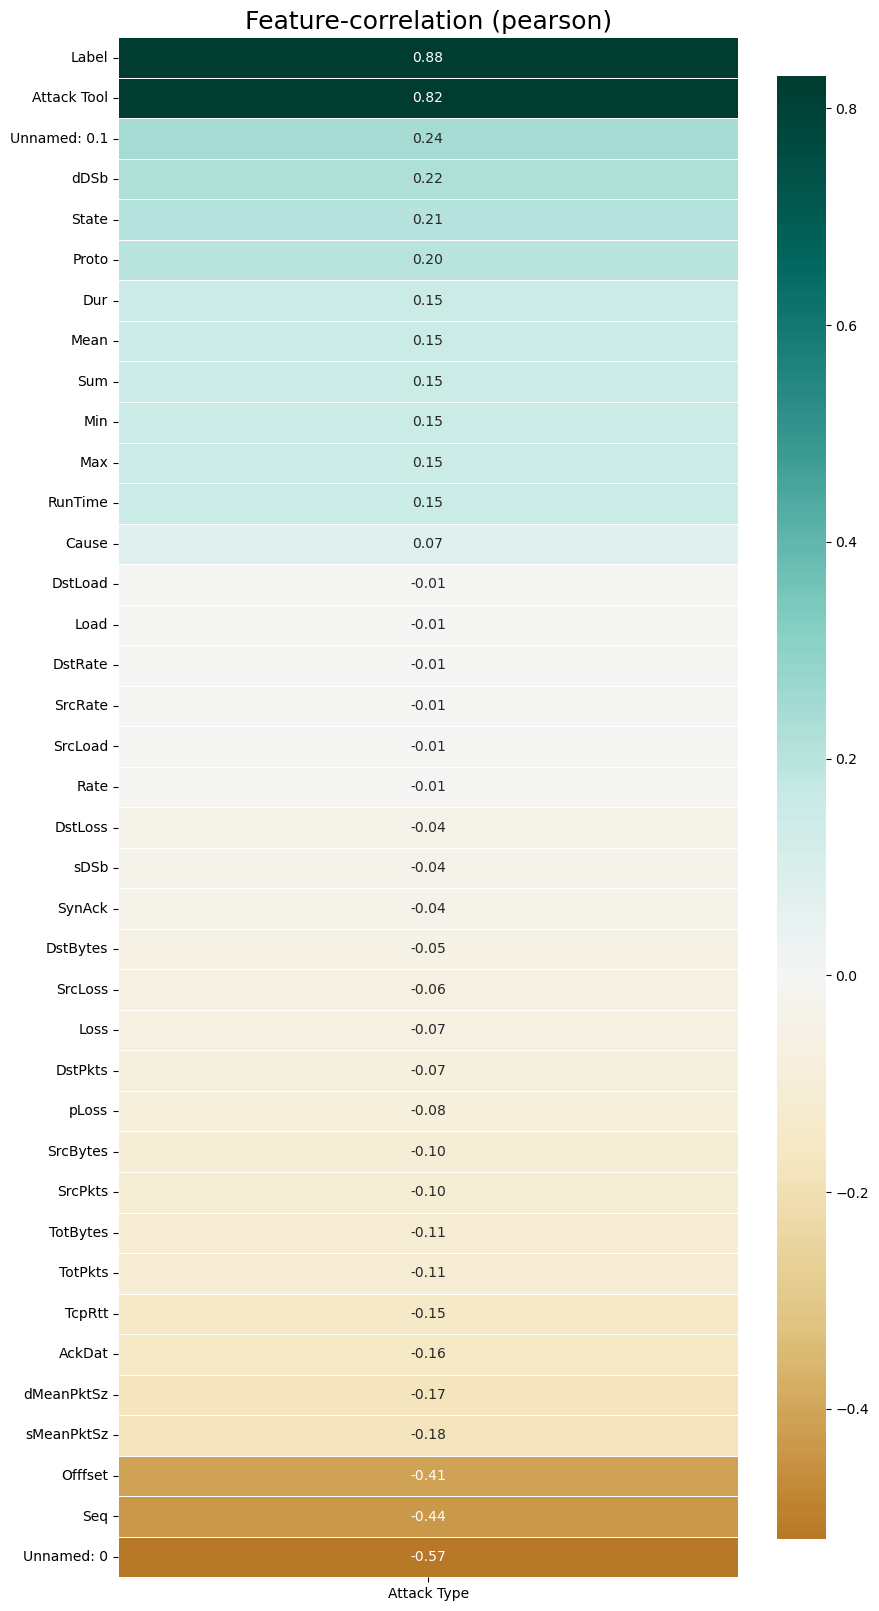

In [23]:
# using coreelation matrix to find the most important features

kl.corr_plot(intro,figsize=(10,20),target='Attack Type')

# features Selection

In [28]:
intro = intro.drop(columns = ["Unnamed: 0.1","Unnamed: 0"], axis=1)

In [29]:
from sklearn.feature_selection import SelectKBest, f_regression

# Assuming your target variable is in 'label' and your features are all other columns
Xs = intro.drop(columns=['Attack Type'])
ys = intro['Attack Type']  # Assuming this is your target variable

# Apply SelectKBest
selector = SelectKBest(score_func=f_regression, k=15)  # Select top 10 features
X_selected = selector.fit_transform(Xs, ys)

# Get selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = Xs.columns[selected_indices]

print("Selected Features:", selected_features)

Selected Features: Index(['Seq', 'Mean', 'Sum', 'Min', 'Max', 'Proto', 'dDSb', 'Offfset',
       'sMeanPktSz', 'dMeanPktSz', 'State', 'TcpRtt', 'AckDat', 'Label',
       'Attack Tool'],
      dtype='object')


# Train_test Split

In [30]:
# Splitting the data into train and test

X = intro[selected_features]
y = intro['Attack Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101) 

# Scaling the data
scaler = StandardScaler()
    
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Implementation
- GAN Architecture + LogisticRegression

In [31]:
# Step 2: GAN Architecture

# Define the Generator
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Generator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        x = self.fc(x)
        return x


In [32]:
# Define the Discriminator
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.fc(x)
        return x

In [33]:
# Step 3: GAN Loss Function and Optimizer
lr = 0.0002
input_dim = X_train.shape[1]
generator = Generator(input_dim, input_dim)
discriminator = Discriminator(input_dim)

# Loss function
criterion = nn.BCELoss()

# Optimizers
optimizer_gen = optim.Adam(generator.parameters(), lr=lr)
optimizer_disc = optim.Adam(discriminator.parameters(), lr=lr)

In [34]:
from torch.autograd import detect_anomaly
from tqdm import tqdm

# Set your hyperparameters
num_epochs = 3
batch_size = 64
input_dim = X_train.shape[1]  # Assuming X_train is your training data

# Create the Generator and Discriminator instances
generator = Generator(input_dim, input_dim)
discriminator = Discriminator(input_dim)

# Define the optimizers for both Generator and Discriminator
optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0002)
optimizer_disc = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

# Loss function
criterion = nn.BCELoss()

# Enable anomaly detection
with detect_anomaly():
    for epoch in range(num_epochs):
        for _ in tqdm(range(len(X_train) // batch_size)):
            selected_indices = np.random.choice(len(X_train), batch_size, replace=False)
            real_samples = torch.Tensor(X_train[selected_indices])
            noise = torch.randn(batch_size, input_dim)
            fake_samples = generator(noise)

            # Discriminator update
            optimizer_disc.zero_grad()
            loss_disc = -(torch.mean(discriminator(real_samples)) - torch.mean(discriminator(fake_samples)))
            loss_disc.backward()
            optimizer_disc.step()

            # Generator update
            optimizer_gen.zero_grad()
            noise = torch.randn(batch_size, input_dim)
            fake_samples = generator(noise)
            loss_gen = -torch.mean(discriminator(fake_samples))
            loss_gen.backward()
            optimizer_gen.step()


100%|████| 11468/11468 [16:57<00:00, 11.27it/s]


In [39]:
# Set the generator in evaluation mode
generator.eval()

# Generate synthetic data
num_samples_to_generate = 1000  
noise = torch.randn(num_samples_to_generate, input_dim)
synthetic_data = generator(noise).detach().numpy() 

# Now 'synthetic_data' contains your synthetic data samples

In [40]:
# Split your real data into training and testing sets
X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(X_train, y_train, test_size=0.2)

# Create labels for the synthetic data (assuming binary classification)
num_samples_synthetic = synthetic_data.shape[0]
y_synthetic = np.zeros(num_samples_synthetic, dtype=int)

# Combine the real and synthetic data
X_combined_train = np.vstack((X_real_train, synthetic_data))
y_combined_train = np.concatenate((y_real_train, y_synthetic))

# Train a classifier (e.g., Logistic Regression)
classifier = LogisticRegression()
classifier.fit(X_combined_train, y_combined_train)

# Make predictions on test data
y_real_pred = classifier.predict(X_real_test)
y_synthetic_pred = classifier.predict(synthetic_data)

# Evaluate the classifier's performance
real_data_accuracy = accuracy_score(y_real_test, y_real_pred)
synthetic_data_accuracy = accuracy_score(y_synthetic, y_synthetic_pred)

# Confusion matrix and classification report for real data
confusion_matrix_real = confusion_matrix(y_real_test, y_real_pred)
classification_report_real = classification_report(y_real_test, y_real_pred)

# Confusion matrix and classification report for synthetic data
confusion_matrix_synthetic = confusion_matrix(y_synthetic, y_synthetic_pred)
classification_report_synthetic = classification_report(y_synthetic, y_synthetic_pred)

print("Real Data Accuracy:", real_data_accuracy)
print("Synthetic Data Accuracy:", synthetic_data_accuracy)
print("\nConfusion Matrix for Real Data:\n", confusion_matrix_real)
print("\nClassification Report for Real Data:\n", classification_report_real)
print("\nConfusion Matrix for Synthetic Data:\n", confusion_matrix_synthetic)
print("\nClassification Report for Synthetic Data:\n", classification_report_synthetic)

Real Data Accuracy: 0.999891008916833
Synthetic Data Accuracy: 1.0

Confusion Matrix for Real Data:
 [[60241     0     0     0     0     0     0     0     0]
 [    0 10593     0     1     0     0     1     1     0]
 [    0     0   160     0     0     0     0     0     0]
 [    0     0     0   698     0     0     0     0     0]
 [    0     0     0     0  2928     0     3     0     1]
 [    0     0     0     0     0  5086     0     0     0]
 [    0     0     0     0     1     0  2713     0     0]
 [    0     0     0     0     0     0     0 62179     0]
 [    0     0     0     0     5     0     3     0  2187]]

Classification Report for Real Data:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     60241
           1       1.00      1.00      1.00     10596
           2       1.00      1.00      1.00       160
           3       1.00      1.00      1.00       698
           4       1.00      1.00      1.00      2932
           5       1.

# Types of Attack with Encoding

- Benign	0
- SYNScan	4
- TCPConnectScan	6
- UDPScan	8
- ICMPFlood	2
- UDPFlood	7
- SYNFlood	3
- HTTPFlood	1
- SlowrateDoS	5

In [44]:
def predict_weather_attack(selected_features):
  """Predicts weather attack type based on user input.

  Args:
    selected_features: A list of feature names.

  Returns:
    The predicted weather attack type.
  """

  input_data = {}

  for feature in selected_features:
    value = input(f"Enter value for {feature}: ")
    input_data[feature] = value

  input_df = pd.DataFrame([input_data])

  # Handle potential errors during prediction
  try:
    prediction = classifier.predict(input_df)
    predicted_attack_type = get_attack_type(prediction[0])
    print(f"Predicted Weather Attack Type: {predicted_attack_type}")
  except Exception as e:
    print(f"Error during prediction: {e}")

def get_attack_type(encoded_value):

  """Maps an encoded value to the corresponding attack type.

  Args:
    encoded_value: The encoded value.

  Returns:
    The attack type corresponding to the encoded value.
  """

  attack_types = {  
    0: "Benign",
    1: "SYNScan",
    2: "TCPConnectScan",
    3: "SYNFlood",
    4: "SYNScan",
    5: "SlowrateDoS",
    6: "TCPConnectScan",
    7: "UDPFlood",
    8: "UDPScan"
  }

  return attack_types.get(encoded_value, "Unknown")

# Call the function with your selected features
#selected_features = [selected_features]  # Replace with your actual features
predict_weather_attack(selected_features)

Enter value for Seq:  108144
Enter value for Mean:  2.578991
Enter value for Sum:  2.578991
Enter value for Min:  2.578991
Enter value for Max:  2.578991
Enter value for Proto:  7
Enter value for dDSb:  6
Enter value for Offfset:  29884024
Enter value for sMeanPktSz:  42.0
Enter value for dMeanPktSz:  0.0
Enter value for State:  6
Enter value for TcpRtt:  0.0000
Enter value for AckDat:  0.000000
Enter value for Label:  0
Enter value for Attack Tool:  0


Predicted Weather Attack Type: UDPFlood


In [43]:
intro.sample(5)

,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sDSb,dDSb,Cause,TotPkts,SrcPkts,DstPkts,TotBytes,SrcBytes,DstBytes,Offfset,sMeanPktSz,dMeanPktSz,Load,SrcLoad,DstLoad,Loss,SrcLoss,DstLoss,pLoss,Rate,SrcRate,DstRate,State,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
402862,108144,2.578991,2.578991,2.578991,2.578991,2.578991,2.578991,7,7,6,2,2,2,0,84,84,0,29884024,42.0,0.0,130.283508,130.283508,0.0,0,0,0,0.0,0.387749,0.387749,0.0,6,0.0000,0.000000,0.000000,0,0,0
1016169,61213,2.573086,2.573086,2.573086,2.573086,2.573086,2.573086,7,7,6,2,2,2,0,84,84,0,20292444,42.0,0.0,130.582504,130.582504,0.0,0,0,0,0.0,0.388638,0.388638,0.0,6,0.0000,0.000000,0.000000,1,7,2
575452,4792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6,7,2,2,2,1,1,132,66,66,2267036,66.0,66.0,0.000000,0.000000,0.0,0,0,0,0.0,0.000000,0.000000,0.0,3,0.0543,0.001573,0.052727,1,1,1
304703,126430,2.593057,2.593057,2.593057,2.593057,2.593057,2.593057,7,7,6,1,2,2,0,84,84,0,21607108,42.0,0.0,129.576797,129.576797,0.0,0,0,0,0.0,0.385645,0.385645,0.0,4,0.0000,0.000000,0.000000,0,0,0
32606,8792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7,7,6,1,1,1,0,42,42,0,818968,42.0,0.0,0.000000,0.000000,0.0,0,0,0,0.0,0.000000,0.000000,0.0,4,0.0000,0.000000,0.000000,1,8,3


In [45]:
import pickle

# create an iterator object with write permission - model.pkl
with open('LogisticRegression_pkl', 'wb') as files:
    pickle.dump(classifier, files)

# Model Implementation


* DBN is a deep neural network architecture that combines unsupervised pre-training with supervised fine-tuning.
* BernoulliRBM is used for unsupervised pre-training of the DBN layers.


In [ ]:
# Defining the RBM model and the classifier (MLP)
rbm = BernoulliRBM(n_components=256, learning_rate=0.06, batch_size=10, n_iter=20, random_state=0)
logistic = linear_model.LogisticRegression(max_iter=10000, solver='lbfgs')

# Use pipeline to chain the RBM and Logistic Regression
rbm_mlp_pipeline = Pipeline(steps=[
    ('rbm', rbm),
    ('logistic', logistic)
])

# Training the model
rbm_mlp_pipeline.fit(X_train, y_train)

# Predicting
y_pred = rbm_mlp_pipeline.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)